# 📊 Student Lifestyle & Performance Analysis

This project analyzes how various lifestyle factors such as study habits, stress levels, sleep patterns, diet quality, and financial behavior influence student academic performance.

The analysis is performed using Python with statistical techniques including linear regression and hypothesis testing (t-test and chi-square test). The objective is to identify significant factors affecting exam scores and validate insights using statistical methods.


## 📂 Data Loading

The dataset used in this analysis is the final combined dataset containing study, health, spending, and diet-related variables.

It includes key features such as:
- Study hours per day  
- Stress level  
- Sleep hours  
- Exam score  
- Diet quality  
- Financial status  

In [7]:
import pandas as pd
df = pd.read_csv("../data/processed/final_combined_dataset.csv")


The dataset was successfully loaded and inspected using basic functions such as `head()`, `info()`, and `columns` to understand its structure and variables.

In [8]:
df.head()

,student_id,study_hours_per_day,sleep_hours,social_media_hours,netflix_hours,stress_level,mental_health_rating,previous_gpa,exam_score,screen_time,...,monthly_spending,monthly_budget,savings,financial_status,spending_category,spending_suggestions,diet_quality,diet_category,food_suggestions,final_recommendation
0,1,7.65,6.2,3.0,0.1,5.8,6.0,4.00,100,3.1,...,11936,10000,-1936,Overspending,High,Reduce unnecessary spending,Poor,Poor,Improve diet quality,"Control spending, Improve diet quality"
1,2,5.70,7.2,0.5,0.4,5.8,6.8,4.00,99,0.9,...,2512,10000,7488,Saving,Low,Maintain balanced spending,Good,Good,Good dietary habits,All good 👍 Maintain your current lifestyle
2,3,2.40,9.2,4.2,0.7,8.0,5.7,3.79,98,4.9,...,7798,10000,2202,Saving,Medium,Maintain balanced spending,Good,Good,Good dietary habits,"Increase study hours, Manage stress better"
3,4,3.40,4.2,4.6,2.3,4.6,8.5,4.00,100,6.9,...,7224,10000,2776,Saving,Medium,Maintain balanced spending,Fair,Fair,Good dietary habits,Improve sleep schedule
4,5,4.70,6.5,0.8,2.7,5.7,9.2,4.00,98,3.5,...,6992,10000,3008,Saving,Medium,Maintain balanced spending,Good,Good,Good dietary habits,All good 👍 Maintain your current lifestyle


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            80000 non-null  int64  
 1   study_hours_per_day   80000 non-null  float64
 2   sleep_hours           80000 non-null  float64
 3   social_media_hours    80000 non-null  float64
 4   netflix_hours         80000 non-null  float64
 5   stress_level          80000 non-null  float64
 6   mental_health_rating  80000 non-null  float64
 7   previous_gpa          80000 non-null  float64
 8   exam_score            80000 non-null  int64  
 9   screen_time           80000 non-null  float64
 10  Suggestions           80000 non-null  object 
 11  exercise_frequency    80000 non-null  int64  
 12  social_activity       80000 non-null  int64  
 13  health_score          80000 non-null  float64
 14  health_category       80000 non-null  object 
 15  family_income_range

In [6]:
df.columns

Index(['student_id', 'study_hours_per_day', 'sleep_hours',
       'social_media_hours', 'netflix_hours', 'stress_level',
       'mental_health_rating', 'previous_gpa', 'exam_score', 'screen_time',
       'Suggestions', 'exercise_frequency', 'social_activity', 'health_score',
       'health_category', 'family_income_range', 'part_time_job',
       'monthly_spending', 'monthly_budget', 'savings', 'financial_status',
       'spending_category', 'spending_suggestions', 'diet_quality',
       'diet_category', 'food_suggestions', 'final_recommendation'],
      dtype='object')

## 🛠️ Data Preprocessing

The dataset was cleaned and prepared before analysis:

- Missing values were removed to ensure data consistency  
- Multiple datasets were merged into a single dataset  
- Categorical variables such as diet quality and financial status were standardized  
- Data was structured for regression and hypothesis testing  

The summary statistics provide an overview of the dataset, including mean, standard deviation, and range of key variables.

In [9]:
df.describe()

,student_id,study_hours_per_day,sleep_hours,social_media_hours,netflix_hours,stress_level,mental_health_rating,previous_gpa,exam_score,screen_time,exercise_frequency,social_activity,health_score,monthly_spending,monthly_budget,savings
count,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.0,80000.000000
mean,40000.500000,4.171644,7.015834,2.501366,1.997754,5.012478,6.804107,3.602448,89.141350,4.499120,3.516587,2.500225,0.521847,7490.255863,10000.0,2509.744137
std,23094.155105,1.995991,1.462714,1.445441,1.155992,1.953174,1.921579,0.462876,11.591497,1.845145,2.291575,1.704292,0.123054,2738.226367,0.0,2738.226367
min,1.000000,0.000000,4.000000,0.000000,0.000000,1.000000,1.000000,1.640000,36.000000,0.000000,0.000000,0.000000,0.000000,2000.000000,10000.0,-4948.000000
25%,20000.750000,2.800000,6.000000,1.200000,1.000000,3.600000,5.500000,3.270000,82.000000,3.200000,2.000000,1.000000,0.440000,5400.750000,10000.0,585.000000
50%,40000.500000,4.130000,7.000000,2.500000,2.000000,5.000000,6.900000,3.790000,93.000000,4.500000,4.000000,2.000000,0.530000,7343.000000,10000.0,2657.000000
75%,60000.250000,5.500000,8.000000,3.800000,3.000000,6.400000,8.200000,4.000000,100.000000,5.800000,6.000000,4.000000,0.610000,9415.000000,10000.0,4599.250000
max,80000.000000,9.550000,11.000000,5.000000,4.000000,10.000000,10.000000,4.000000,100.000000,9.000000,7.000000,5.000000,1.000000,14948.000000,10000.0,8000.000000


The correlation matrix shows that study hours and previous GPA have a strong positive relationship with exam scores, while stress level has a negative impact. Other variables such as sleep and health show moderate influence, whereas screen time and social activity have weak correlations.

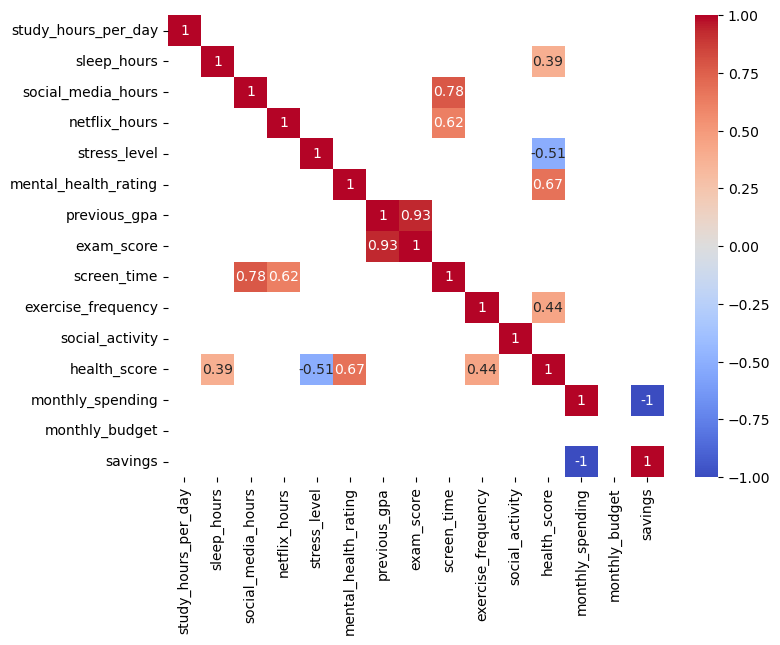

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

corr = df.corr(numeric_only=True)

corr_filtered = corr[(corr > 0.3) | (corr < -0.3)]

plt.figure(figsize=(8,6))
sns.heatmap(corr_filtered, annot=True, cmap='coolwarm')
plt.show()

The scatter plot with the fitted trend line shows a clear positive relationship between study hours and exam scores. Despite the dense distribution of points, the upward trend line indicates that increased study time is associated with better academic performance.

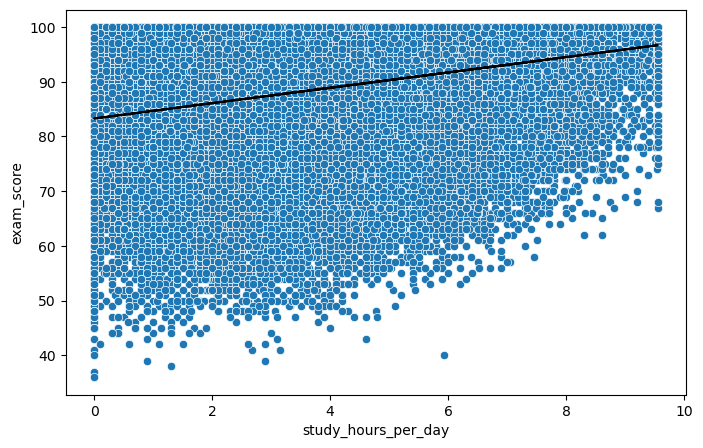

In [34]:
import numpy as np

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='study_hours_per_day',y='exam_score',data=df)

plt.plot(df['study_hours_per_day'], p(df['study_hours_per_day']), color='black')

plt.show()

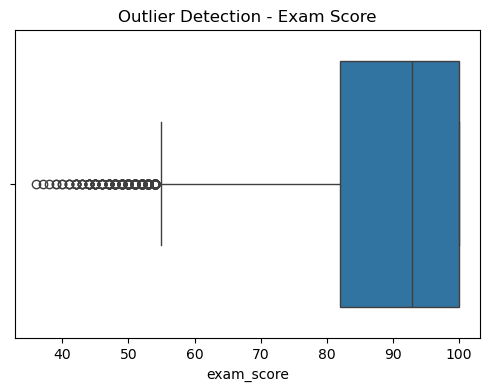

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(x=df['exam_score'])
plt.title("Outlier Detection - Exam Score")
plt.show()

In [51]:
Q1 = df['exam_score'].quantile(0.25)
Q3 = df['exam_score'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['exam_score'] < lower) | (df['exam_score'] > upper)]

print("Number of outliers:", len(outliers))

Number of outliers: 467


## 📊 Problem Statements and Solutions

## 📌 Analytical Approach

Each problem is addressed using appropriate statistical or machine learning techniques to validate relationships observed in the dataset.

### 🔍 Problem 1: Predicting Exam Performance Using Lifestyle Factors

#### 🛠️ Solution: Linear Regression Model

In [40]:
X = df[['study_hours_per_day', 'stress_level', 'sleep_hours']]
y = df['exam_score']

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("Coefficients:", model.coef_)

R2 Score: 0.08346631572783036
Coefficients: [ 1.39624632 -0.68954303  0.72256913]


### 🔍 Problem 2: Impact of Study Hours on Academic Performance

#### 🛠️ Solution: Independent Sample T-Test

In [44]:
from scipy import stats

avg = df['study_hours_per_day'].mean()

high = df[df['study_hours_per_day'] > avg]['exam_score']
low = df[df['study_hours_per_day'] <= avg]['exam_score']

t_stat, p_val = stats.ttest_ind(high, low)

print("p-value:",p_val)

p-value: 0.0


### 🔍 Problem 3: Effect of Stress Level on Exam Scores

#### 🛠️ Solution: Hypothesis Testing (T-Test)

In [46]:
low_stress = df[df['stress_level'] <= df['stress_level'].median()]['exam_score']
high_stress = df[df['stress_level'] > df['stress_level'].median()]['exam_score']

t_stat, p_val = stats.ttest_ind(low_stress, high_stress)

print("p-value:", format(p_val,".2e"))

p-value: 4.14e-161


### 🔍 Problem 4: Relationship Between Diet Quality and Performance

#### 🛠️ Solution: Chi-Square Test of Independence

In [47]:
from scipy.stats import chi2_contingency

df['performance'] = pd.cut(df['exam_score'],
                          bins=[0, 60, 80, 100],
                          labels=['Low', 'Medium', 'High'])

table = pd.crosstab(df['diet_quality'], df['performance'])

chi2, p_val, dof, expected = chi2_contingency(table)

print("p-value:", p_val)

p-value: 0.13956656919219032


### 🔍 Problem 5: Influence of Financial Behavior on Academic Outcomes

#### 🛠️ Solution: Hypothesis Testing (T-Test)

In [48]:
saving = df[df['financial_status'] == 'Saving']['exam_score']
overspending = df[df['financial_status'] == 'Overspending']['exam_score']

t_stat, p_val = stats.ttest_ind(saving, overspending)

print("p-value:", p_val)

p-value: 0.263682688035277
